# 04 · Behavioural profiling and segmentation
**Question:** Is an account's behaviour unusual *for that account*, and does one global threshold treat busy and quiet accounts fairly?

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


In [2]:
prof = T("account_profiles")
prof[["tx_count", "median_amount", "amount_std", "max_amount", "in_amount", "out_amount", "inflow_outflow_ratio",
      "unique_counterparties", "tx_per_counterparty", "active_weeks"]].describe().T

,count,mean,std,min,25%,50%,75%,max
tx_count,20000.0,12.0543,12.3140,0.00,7.0000,10.0000,14.0000,373.0000
median_amount,19980.0,273.7979,128.5942,2.93,168.9400,248.4450,357.7400,599.9100
amount_std,19926.0,111.4817,44.9328,0.00,82.2876,111.8812,141.1283,333.0402
max_amount,19980.0,461.1942,111.2313,101.77,382.3200,489.8200,555.0900,599.9100
in_amount,20000.0,1664.1856,2065.1245,0.00,781.8200,1248.5300,1891.4800,51073.6100
out_amount,20000.0,1664.1856,2005.6101,0.00,733.3425,1250.8600,2100.0975,70082.0000
inflow_outflow_ratio,19979.0,1.7619,3.7849,0.00,0.5417,0.9271,1.6330,113.5840
unique_counterparties,19980.0,11.7138,11.8052,1.00,7.0000,10.0000,13.0000,372.0000
tx_per_counterparty,19980.0,1.0254,0.1269,1.00,1.0000,1.0000,1.0000,3.1250
active_weeks,19980.0,7.6982,2.8823,1.00,6.0000,7.0000,9.0000,22.0000


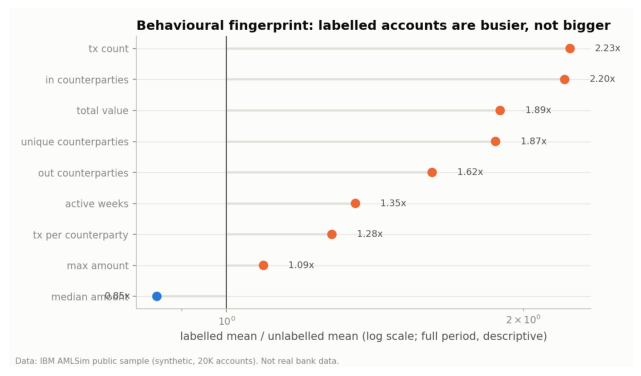

,metric,labelled_median,unlabelled_median,labelled_mean,unlabelled_mean,labelled_p90,unlabelled_p90
0,tx_count,18.0000,9.000,24.2262,10.8595,36.0000,18.00
1,median_amount,214.6900,252.425,235.9142,277.5579,403.3135,478.61
2,max_amount,529.4350,483.540,498.7502,457.4667,591.3600,584.44
3,unique_counterparties,14.0000,9.000,20.3509,10.8566,32.0000,18.00
4,tx_per_counterparty,1.1765,1.000,1.2793,1.0002,1.7143,1.00
5,in_counterparties,7.0000,4.000,11.6680,5.2969,22.7000,9.00
6,out_counterparties,6.0000,5.000,8.9917,5.5626,12.0000,9.00
7,active_weeks,10.0000,7.000,10.0837,7.4614,14.0000,11.00
8,total_value,3826.9500,2536.585,5840.9232,3082.6585,9531.3890,5473.09


In [3]:
show("fig04_behavioural_fingerprint", 9)
T("labelled_vs_unlabelled_profiles")

In [4]:
# descriptive activity tiers (full period, EDA only)
T("activity_tier_summary")

,activity_tier,accounts,labelled_rate,median_tx,median_counterparties
0,high (p90-p99),1775,0.3369,25.0,24.0
1,inactive,20,0.0000,0.0,NaN
2,low (<= median),11102,0.0230,7.0,7.0
3,medium (median-p90),6918,0.1207,13.0,13.0
4,very high (> p99),185,0.6270,55.0,53.0


### Point-in-time segments and segment-specific thresholds
Segments are terciles of each account's *historical* weekly transaction rate (history only). We compare the global
velocity threshold (VEL-01) with a per-segment 99th-percentile threshold on held-out accounts in test weeks.

In [5]:
print("segment cut-points (historical tx/week):", KM["segment_cuts"])
T("segment_threshold_comparison")

segment cut-points (historical tx/week): [0.6666666666666666, 1.0]


,segment,threshold_type,threshold,account_weeks,alerts,alert_rate,precision,segment_base_rate
0,no history,global threshold,6.0,56,0,0.0000,NaN,0.0000
1,no history,segment threshold,4.0,56,0,0.0000,NaN,0.0000
2,low,global threshold,6.0,11217,23,0.0021,1.0000,0.0407
3,low,segment threshold,4.0,11217,143,0.0127,0.3776,0.0407
4,medium,global threshold,6.0,9629,38,0.0039,0.8947,0.0829
5,medium,segment threshold,5.0,9629,104,0.0108,0.6923,0.0829
6,high,global threshold,6.0,9802,281,0.0287,0.8221,0.2498
7,high,segment threshold,12.0,9802,51,0.0052,0.8824,0.2498


In [6]:
T("segment_threshold_overall")[["approach", "alerts", "alert_precision", "account_recall", "false_positive_accounts"]]

,approach,alerts,alert_precision,account_recall,false_positive_accounts
0,VEL-01 global,342,0.8421,0.2181,40
1,VEL-01 segment-specific,298,0.5738,0.1606,122


**Reading:** compare precision and false positives in the table above. The segment-specific version is adopted only
if it is better; the decision is recorded in `reports/findings.md`.

In [7]:
# behavioural baseline example: one account's weekly features vs its own history
acc = int(T("alert_queue").sort_values("risk_score", ascending=False).account_id.iloc[0])
pd.read_sql_query("SELECT week, n_tx, hist_weekly_mean, velocity_ratio, new_cp, n_cp, mean_amt, hist_amt_median "
                  "FROM account_week_features WHERE account_id = ? ORDER BY week", con, params=(acc,))

,week,n_tx,hist_weekly_mean,velocity_ratio,new_cp,n_cp,mean_amt,hist_amt_median
0,5,17.0,9.0000,1.8000,17.0,17,332.9400,323.79
1,6,15.0,13.0000,1.1429,15.0,15,335.8920,323.79
2,7,19.0,13.6667,1.3636,19.0,19,329.6963,323.79
3,8,21.0,15.0000,1.3750,21.0,21,335.9667,323.79
4,9,22.0,16.2000,1.3372,22.0,22,295.5486,323.79
5,10,21.0,17.1667,1.2110,21.0,21,323.4281,323.79
6,11,22.0,17.7143,1.2290,22.0,22,320.9509,323.79
7,12,30.0,18.2500,1.6104,29.0,30,295.1173,323.79
8,13,22.0,19.5556,1.1189,22.0,22,305.6577,323.79
9,14,36.0,19.8000,1.7788,36.0,36,296.5128,323.79
